# Phase 2B Preprocessing

Convert (cleaned IMU CSV + Label Studio annotations + pose .npy) into per-punch labeled clips for force/speed regression training.

**Inputs per session:**
- `data/raw/with_hardware/{subject}/{session}_imu_cleaned.csv` (IMU with sync_offset_ms)
- `data/processed/with_hardware/{subject}/{session}_pose_norm.npy` (skeleton from Phase 1)
- `data/annotations/with_hardware/{subject}/labelstudio/{subject}_annotations.json`
- `data/metadata/with_hardware/subjects.csv` (body weight per subject)

**Outputs:**
- `data/clips/with_hardware/{class}/{clip_id}.npy` (pose data per punch)
- `data/metadata/with_hardware/labels.csv` (peak force, peak speed, body weight per clip)

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path("../../")

# Input paths
ANNOTATIONS_DIR = PROJECT_ROOT / "data" / "annotations" / "with_hardware"
RAW_ROOT = PROJECT_ROOT / "data" / "raw" / "with_hardware"
PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed" / "with_hardware"
SUBJECTS_CSV = PROJECT_ROOT / "data" / "metadata" / "with_hardware" / "subjects.csv"

# Output paths
CLIPS_DIR = PROJECT_ROOT / "data" / "clips" / "with_hardware"
LABELS_CSV = PROJECT_ROOT / "data" / "metadata" / "with_hardware" / "labels.csv"

# Constants
VIDEO_FPS = 30.0
ARM_MASS_FRACTION = 0.023        # de Leva 1996 — arm = 2.3% of body weight
GRAVITY_MPS2 = 9.81              # for converting g to m/s²
FRAME_PADDING = 5                # ±N frames buffer for finding peak in IMU
PUNCH_CLASSES = {"jab", "cross", "hook", "uppercut"}

print(f"Project root: {PROJECT_ROOT.resolve()}")
print(f"Annotations dir: {ANNOTATIONS_DIR}")

Project root: C:\Development\OJT\VTCA2026\depth-pose-boxing
Annotations dir: ..\..\data\annotations\with_hardware


## Section A — Load Subject Metadata

Load body weights for each subject from `subjects.csv`.

In [2]:
subjects_df = pd.read_csv(SUBJECTS_CSV)
print(f"Loaded {len(subjects_df)} subjects:")
print(subjects_df.to_string(index=False))

# Convenience lookup
def get_body_weight(subject_id: str) -> float | None:
    row = subjects_df[subjects_df["subject_id"] == subject_id]
    if len(row) == 0:
        return None
    return float(row["body_weight_kg"].iloc[0])

Loaded 4 subjects:
subject_id person_id  body_weight_kg hand_dominant
 subject01  person01            58.0         right
 subject02  person01            58.0         right
 subject03  person01            58.0         right
 subject04  person02            45.0         right


## Section B — Helper Functions

Functions for parsing Label Studio JSON, finding the sync clap, and computing punch labels from IMU data.

In [3]:
def strip_labelstudio_prefix(filename: str) -> str:
    """Label Studio prepends a hash to filenames. Strip it."""
    parts = filename.split("-", 1)
    if len(parts) == 2 and len(parts[0]) == 8:
        return parts[1]
    return filename


def parse_labelstudio_export(json_path: Path) -> list[dict]:
    """Parse Label Studio JSON-MIN export into a list of annotation dicts.
    
    Returns list of dicts with:
        video_filename, start_frame, end_frame, class
    
    Expects timeline labels stored under the 'class' key, with each entry
    containing 'ranges' (list of {start, end}) and 'timelinelabels' (list of class names).
    """
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    annotations = []
    
    for task in data:
        # Find the video filename (under 'video' key in Label Studio JSON-MIN)
        video_path = task.get("video", "")
        if not video_path:
            continue
        
        video_filename = video_path.split("/")[-1]
        video_filename = strip_labelstudio_prefix(video_filename)
        
        # Timeline annotations are under the 'class' key
        timeline_annotations = task.get("class", [])
        if not isinstance(timeline_annotations, list):
            continue
        
        for item in timeline_annotations:
            if not isinstance(item, dict):
                continue
            
            labels = item.get("timelinelabels", [])
            ranges = item.get("ranges", [])
            
            if not labels or not ranges:
                continue
            
            label = labels[0].lower() if labels else None
            if label is None:
                continue
            
            # Each annotation can have multiple ranges (separate punches with same label)
            for r in ranges:
                start_frame = r.get("start")
                end_frame = r.get("end")
                if start_frame is None or end_frame is None:
                    continue
                
                annotations.append({
                    "video_filename": video_filename,
                    "start_frame": int(start_frame),
                    "end_frame": int(end_frame),
                    "class": label,
                })
    
    return annotations

In [4]:
def find_first_clap_frame(annotations: list[dict], video_filename: str) -> int | None:
    """Find the start_frame of the first 'clap' annotation for this video."""
    clap_annotations = [
        a for a in annotations
        if a["video_filename"] == video_filename and a["class"] == "clap"
    ]
    if not clap_annotations:
        return None
    clap_annotations.sort(key=lambda a: a["start_frame"])
    return clap_annotations[0]["start_frame"]


def frame_to_ms_since_clap(frame: int, clap_frame: int, fps: float = VIDEO_FPS) -> float:
    """Convert a video frame number to milliseconds since clap."""
    return (frame - clap_frame) / fps * 1000.0

from ahrs.filters import Madgwick
from scipy.signal import detrend

def compute_punch_labels(imu_df: pd.DataFrame, punch_start_ms: float,
                          punch_end_ms: float, body_weight_kg: float,
                          padding_ms: float = FRAME_PADDING / VIDEO_FPS * 1000.0,
                          pre_punch_calibration_ms: float = 2000.0) -> dict | None:
    """Extract peak force and peak speed for one punch using sensor fusion.
    
    Uses Madgwick filter for orientation tracking and linear detrending
    to correct accumulated velocity drift.
    
    Args:
        pre_punch_calibration_ms: time before punch for orientation initialization
                                  (longer = better Madgwick convergence; 2000ms = 2s)
    """
    window_start = punch_start_ms - padding_ms
    window_end = punch_end_ms + padding_ms
    
    # Include longer pre-punch period for orientation calibration
    calibration_window_start = window_start - pre_punch_calibration_ms
    
    full_window = imu_df[
        (imu_df["sync_offset_ms"] >= calibration_window_start) &
        (imu_df["sync_offset_ms"] <= window_end)
    ].copy().reset_index(drop=True)
    
    if len(full_window) < 50:  # need enough samples for Madgwick to converge
        return None
    
    # Extract accel (g → m/s²) and gyro (deg/s → rad/s)
    accel_data = full_window[["ax", "ay", "az"]].values * GRAVITY_MPS2
    gyro_data = np.deg2rad(full_window[["gx_dps", "gy_dps", "gz_dps"]].values)
    
    # Compute time deltas
    time_s = full_window["sync_offset_ms"].values / 1000.0
    dt_array = np.diff(time_s)
    
    if len(dt_array) == 0 or dt_array.mean() <= 0:
        return None
    
    median_dt = float(np.median(dt_array))
    sample_rate = 1.0 / median_dt
    
    # Initialize Madgwick with appropriate gain
    # Higher beta = faster convergence but more noise
    madgwick = Madgwick(frequency=sample_rate, gain=0.1)
    
    n_samples = len(full_window)
    quaternions = np.zeros((n_samples, 4))
    
    # Initialize first quaternion from accelerometer (assumes mostly gravity)
    # This gives Madgwick a head start instead of starting at identity
    initial_accel = accel_data[:5].mean(axis=0)
    accel_norm = initial_accel / np.linalg.norm(initial_accel)
    # Compute quaternion that aligns gravity_world to initial_accel direction
    # Simplified: just use accelerometer to set initial roll/pitch
    pitch = np.arcsin(-accel_norm[0])
    roll = np.arctan2(accel_norm[1], accel_norm[2])
    yaw = 0.0
    quaternions[0] = euler_to_quaternion(roll, pitch, yaw)
    
    for i in range(1, n_samples):
        quaternions[i] = madgwick.updateIMU(
            quaternions[i-1],
            gyr=gyro_data[i],
            acc=accel_data[i]
        )
    
    # Subtract gravity in IMU frame at each sample
    gravity_world = np.array([0, 0, GRAVITY_MPS2])
    linear_accel = np.zeros_like(accel_data)
    for i in range(n_samples):
        q = quaternions[i]
        gravity_imu = quaternion_rotate(quaternion_conjugate(q), gravity_world)
        linear_accel[i] = accel_data[i] - gravity_imu
    
    # Restrict to actual punch window
    in_punch = (full_window["sync_offset_ms"] >= window_start) & \
               (full_window["sync_offset_ms"] <= window_end)
    punch_indices = np.where(in_punch)[0]
    
    if len(punch_indices) < 3:
        return None
    
    linear_accel_punch = linear_accel[punch_indices]
    linear_accel_mag = np.linalg.norm(linear_accel_punch, axis=1)
    
    peak_accel_mps2 = float(linear_accel_mag.max())
    peak_accel_g = peak_accel_mps2 / GRAVITY_MPS2
    
    arm_mass = body_weight_kg * ARM_MASS_FRACTION
    peak_force_N = arm_mass * peak_accel_mps2
    
    # Rotate linear acceleration to world frame for integration
    linear_accel_world = np.zeros_like(linear_accel_punch)
    for i, punch_idx in enumerate(punch_indices):
        q = quaternions[punch_idx]
        linear_accel_world[i] = quaternion_rotate(q, linear_accel_punch[i])
    
    punch_time_s = time_s[punch_indices]
    punch_dt = np.diff(punch_time_s)
    
    if len(punch_dt) == 0:
        return None
    
    # Integrate to get velocity
    velocity = np.zeros_like(linear_accel_world)
    for i in range(1, len(velocity)):
        velocity[i] = velocity[i-1] + linear_accel_world[i-1] * punch_dt[i-1]
    
    # Apply linear detrending to remove integration drift
    # Assumes the wrist starts and ends approximately at rest within the window
    velocity_detrended = np.column_stack([
        detrend(velocity[:, 0]),
        detrend(velocity[:, 1]),
        detrend(velocity[:, 2]),
    ])
    
    speed = np.linalg.norm(velocity_detrended, axis=1)
    peak_speed_mps = float(speed.max())
    
    return {
        "peak_force_N": peak_force_N,
        "peak_speed_mps": peak_speed_mps,
        "peak_accel_g": peak_accel_g,
        "n_imu_samples": int(in_punch.sum()),
    }


def quaternion_conjugate(q: np.ndarray) -> np.ndarray:
    return np.array([q[0], -q[1], -q[2], -q[3]])


def quaternion_rotate(q: np.ndarray, v: np.ndarray) -> np.ndarray:
    w, x, y, z = q
    return np.array([
        (1 - 2*y*y - 2*z*z)*v[0] + 2*(x*y - w*z)*v[1] + 2*(x*z + w*y)*v[2],
        2*(x*y + w*z)*v[0] + (1 - 2*x*x - 2*z*z)*v[1] + 2*(y*z - w*x)*v[2],
        2*(x*z - w*y)*v[0] + 2*(y*z + w*x)*v[1] + (1 - 2*x*x - 2*y*y)*v[2]
    ])


def euler_to_quaternion(roll: float, pitch: float, yaw: float) -> np.ndarray:
    """Convert Euler angles (radians) to quaternion [w, x, y, z]."""
    cr, sr = np.cos(roll/2), np.sin(roll/2)
    cp, sp = np.cos(pitch/2), np.sin(pitch/2)
    cy, sy = np.cos(yaw/2), np.sin(yaw/2)
    return np.array([
        cr*cp*cy + sr*sp*sy,
        sr*cp*cy - cr*sp*sy,
        cr*sp*cy + sr*cp*sy,
        cr*cp*sy - sr*sp*cy
    ])

## Section C — Process All Subjects

For each subject, parse annotations and IMU data, then produce labeled clips.

In [5]:
# Find all subjects with annotations
subject_dirs = sorted([
    d for d in ANNOTATIONS_DIR.iterdir()
    if d.is_dir() and (d / "labelstudio").exists()
])
print(f"Found {len(subject_dirs)} subjects with annotations:")
for d in subject_dirs:
    print(f"  {d.name}")

# Container for all clip metadata
all_clip_rows = []
skipped_count = 0
processed_count = 0

# Ensure output directories exist
for cls in PUNCH_CLASSES:
    (CLIPS_DIR / cls).mkdir(parents=True, exist_ok=True)


for subject_dir in subject_dirs:
    subject_id = subject_dir.name
    body_weight = get_body_weight(subject_id)
    
    if body_weight is None:
        print(f"\n[SKIP] {subject_id}: no body weight in subjects.csv")
        continue
    
    print(f"\n=== {subject_id} (body weight: {body_weight} kg) ===")
    
    # Load all annotations for this subject
    labelstudio_files = list((subject_dir / "labelstudio").glob("*.json"))
    if not labelstudio_files:
        print(f"  No annotation files found.")
        continue
    
    annotations = []
    for f in labelstudio_files:
        annotations.extend(parse_labelstudio_export(f))
    
    if not annotations:
        print(f"  No annotations parsed from files.")
        continue
    
    # Group by video
    videos = sorted(set(a["video_filename"] for a in annotations))
    
    for video_filename in videos:
        video_stem = Path(video_filename).stem
        
        # Find the clap
        clap1_frame = find_first_clap_frame(annotations, video_filename)
        if clap1_frame is None:
            print(f"  [SKIP] {video_filename}: no clap annotation")
            skipped_count += 1
            continue
        
        # Load IMU CSV
        imu_path = RAW_ROOT / subject_id / f"{video_stem}_imu_cleaned.csv"
        if not imu_path.exists():
            print(f"  [SKIP] {video_filename}: no IMU CSV at {imu_path}")
            skipped_count += 1
            continue
        imu_df = pd.read_csv(imu_path)
        if "sync_offset_ms" not in imu_df.columns:
            print(f"  [SKIP] {video_filename}: IMU CSV has no sync_offset_ms column")
            skipped_count += 1
            continue
        
        # Load pose .npy
        pose_path = PROCESSED_ROOT / subject_id / f"{video_stem}_pose_norm.npy"
        if not pose_path.exists():
            print(f"  [SKIP] {video_filename}: no pose .npy at {pose_path}")
            skipped_count += 1
            continue
        pose_array = np.load(pose_path)
        
        # Get all punch annotations for this video
        video_punches = [
            a for a in annotations
            if a["video_filename"] == video_filename and a["class"] in PUNCH_CLASSES
        ]
        video_punches.sort(key=lambda a: a["start_frame"])
        
        # Extract distance and hand from filename (assumes format like jab_1m_right.mp4)
        parts = video_stem.split("_")
        distance_m = "unknown"
        hand = "unknown"
        for p in parts:
            if p.endswith("m") and p[:-1].isdigit():
                distance_m = p[:-1]
            if p.lower() in ("left", "right"):
                hand = p.lower()
        
        print(f"  Processing {video_filename}: clap at frame {clap1_frame}, "
              f"{len(video_punches)} punches")
        
        # Per-class counter for clip_id
        per_class_counter = {cls: 0 for cls in PUNCH_CLASSES}
        
        for punch in video_punches:
            punch_class = punch["class"]
            per_class_counter[punch_class] += 1
            counter_str = f"c{per_class_counter[punch_class]:03d}"
            subj_num = subject_id.replace("subject", "")
            clip_id = f"s{subj_num}_{punch_class}_{distance_m}m_{hand}_{counter_str}"
            
            # Compute timing relative to clap
            punch_start_ms = frame_to_ms_since_clap(punch["start_frame"], clap1_frame)
            punch_end_ms = frame_to_ms_since_clap(punch["end_frame"], clap1_frame)
            
            # Compute labels from IMU
            labels = compute_punch_labels(
                imu_df, punch_start_ms, punch_end_ms, body_weight
            )
            
            if labels is None:
                print(f"    [SKIP] {clip_id}: no/insufficient IMU samples in window")
                skipped_count += 1
                continue
            
            # Extract pose clip
            if punch["end_frame"] >= pose_array.shape[0]:
                print(f"    [SKIP] {clip_id}: end_frame {punch['end_frame']} "
                      f"exceeds pose array length {pose_array.shape[0]}")
                skipped_count += 1
                continue
            
            pose_clip = pose_array[punch["start_frame"]:punch["end_frame"] + 1]
            
            # Save clip
            clip_path = CLIPS_DIR / punch_class / f"{clip_id}.npy"
            np.save(clip_path, pose_clip)
            
            all_clip_rows.append({
                "clip_id": clip_id,
                "subject_id": subject_id,
                "video_filename": video_filename,
                "class": punch_class,
                "hand": hand,
                "distance_m": distance_m,
                "start_frame": punch["start_frame"],
                "end_frame": punch["end_frame"],
                "frame_count": punch["end_frame"] - punch["start_frame"] + 1,
                "body_weight_kg": body_weight,
                "peak_force_N": labels["peak_force_N"],
                "peak_speed_mps": labels["peak_speed_mps"],
                "peak_accel_g": labels["peak_accel_g"],
                "n_imu_samples": labels["n_imu_samples"],
            })
            processed_count += 1

print(f"\n=== Summary ===")
print(f"Clips processed: {processed_count}")
print(f"Clips skipped:   {skipped_count}")

Found 4 subjects with annotations:
  subject01
  subject02
  subject03
  subject04

=== subject01 (body weight: 58.0 kg) ===
  Processing cross_1m_left.mp4: clap at frame 23, 10 punches
  Processing cross_1m_right.mp4: clap at frame 31, 10 punches
  Processing cross_2m_left.mp4: clap at frame 66, 10 punches
  Processing cross_2m_right.mp4: clap at frame 35, 10 punches
  Processing hook_1m_left.mp4: clap at frame 76, 10 punches
  Processing hook_1m_right.mp4: clap at frame 25, 10 punches
  Processing hook_2m_left.mp4: clap at frame 60, 10 punches
  Processing hook_2m_right.mp4: clap at frame 45, 10 punches
  Processing jab_1m_left.mp4: clap at frame 71, 10 punches
  Processing jab_1m_right.mp4: clap at frame 26, 10 punches
  Processing jab_2m_left.mp4: clap at frame 82, 10 punches
  Processing jab_2m_right.mp4: clap at frame 26, 10 punches
  Processing uppercut_1m_left.mp4: clap at frame 27, 10 punches
  Processing uppercut_1m_right.mp4: clap at frame 53, 10 punches
  Processing uppercu

## Section D — Save Labels CSV

Save the per-clip labels with metadata.

In [6]:
labels_df = pd.DataFrame(all_clip_rows)
labels_df = labels_df.sort_values(["subject_id", "class", "clip_id"]).reset_index(drop=True)

LABELS_CSV.parent.mkdir(parents=True, exist_ok=True)
labels_df.to_csv(LABELS_CSV, index=False)

print(f"Saved {len(labels_df)} clip labels to: {LABELS_CSV}")
print(f"\nClass distribution:")
print(labels_df["class"].value_counts())

print(f"\nPer-subject counts:")
print(labels_df.groupby("subject_id").size())

Saved 802 clip labels to: ..\..\data\metadata\with_hardware\labels.csv

Class distribution:
class
cross       201
hook        201
jab         200
uppercut    200
Name: count, dtype: int64

Per-subject counts:
subject_id
subject01    160
subject02    160
subject03    241
subject04    241
dtype: int64


## Section E — Sanity Check

Inspect the distribution of peak force and peak speed to verify the labels look reasonable.

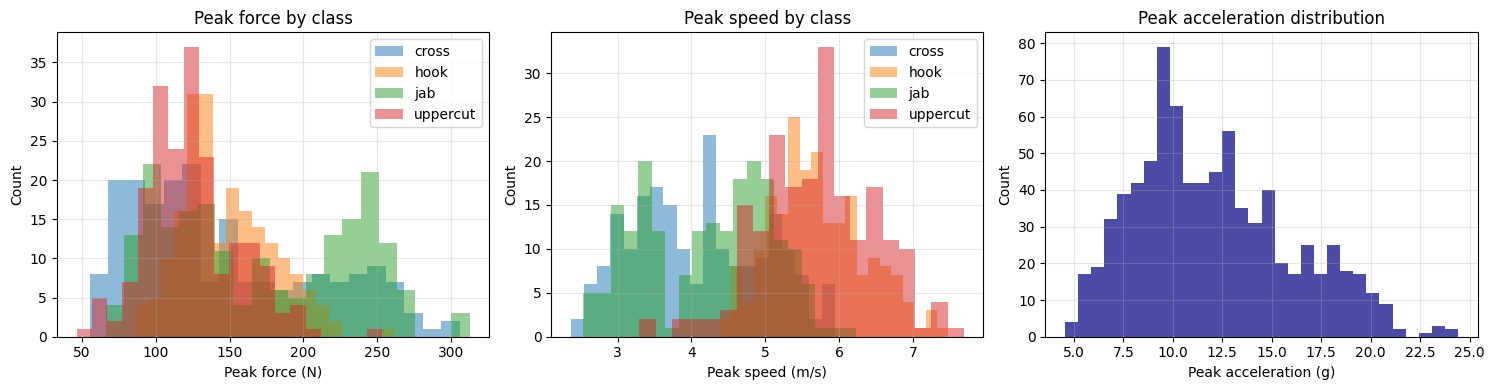


Summary statistics:
       peak_force_N  peak_speed_mps  peak_accel_g
count    802.000000      802.000000    802.000000
mean     147.233228        4.929828     12.050729
std       52.378303        1.110403      3.936108
min       46.227271        2.365584      4.552908
25%      109.072285        4.173026      9.186961
50%      132.485176        5.086166     11.507524
75%      176.758809        5.715815     14.568541
max      312.550848        7.690041     24.419133


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Peak force distribution by class
for cls in sorted(labels_df["class"].unique()):
    cls_data = labels_df[labels_df["class"] == cls]["peak_force_N"]
    axes[0].hist(cls_data, bins=20, alpha=0.5, label=cls)
axes[0].set_xlabel("Peak force (N)")
axes[0].set_ylabel("Count")
axes[0].set_title("Peak force by class")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Peak speed distribution by class
for cls in sorted(labels_df["class"].unique()):
    cls_data = labels_df[labels_df["class"] == cls]["peak_speed_mps"]
    axes[1].hist(cls_data, bins=20, alpha=0.5, label=cls)
axes[1].set_xlabel("Peak speed (m/s)")
axes[1].set_ylabel("Count")
axes[1].set_title("Peak speed by class")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Peak acceleration distribution
axes[2].hist(labels_df["peak_accel_g"], bins=30, color="navy", alpha=0.7)
axes[2].set_xlabel("Peak acceleration (g)")
axes[2].set_ylabel("Count")
axes[2].set_title("Peak acceleration distribution")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSummary statistics:")
print(labels_df[["peak_force_N", "peak_speed_mps", "peak_accel_g"]].describe())

In [8]:
print(labels_df.groupby(["subject_id", "class"])[["peak_force_N", "peak_speed_mps"]].mean())

                     peak_force_N  peak_speed_mps
subject_id class                                 
subject01  cross       184.862316        4.249888
           hook        125.639939        5.306321
           jab         234.581744        4.915021
           uppercut    120.526668        5.732627
subject02  cross       237.641101        5.327692
           hook        172.611724        5.948994
           jab         240.036168        4.947459
           uppercut    170.474959        6.745530
subject03  cross        94.474723        3.304375
           hook        161.225891        5.955537
           jab         109.951725        3.303182
           uppercut    124.363470        5.689554
subject04  cross       110.603861        3.921378
           hook        133.386954        5.567214
           jab         141.387774        4.204009
           uppercut     97.176172        5.003147
